# Adaptive Hedge — experimental study

**Paper.** T. van Erven, P. Grünwald, W. M. Koolen, S. de Rooij, *Adaptive Hedge*, NeurIPS 2011
([arXiv:1110.6416](https://arxiv.org/abs/1110.6416)).

This notebook implements **Hedge with a fixed learning rate** and **AdaHedge** from scratch
(`numpy` + `matplotlib` only) and compares them across six loss regimes of increasing difficulty.

## Protocol

At each round $t=1,\dots,T$ the learner publishes a distribution $\boldsymbol w_t$ over $K$ actions,
every action $k$ then incurs a loss $\ell_t^k\in\{0,1\}$, and the learner pays
$\boldsymbol w_t\cdot\boldsymbol\ell_t$. After $T$ rounds,

$$R(T)\;=\;\sum_{t=1}^{T}\boldsymbol w_t\cdot\boldsymbol\ell_t\;-\;L_T^{*},
\qquad L_T^{*}=\min_{1\le k\le K}\sum_{t=1}^{T}\ell_t^{k}.$$

## Algorithms

| | learning rate | knowledge required |
|---|---|---|
| `Hedge 2η*`  | $2\eta^{*}$ | post-hoc $L_T^{*}$ |
| `Hedge η*`   | $\eta^{*}=\sqrt{2\ln K/L_T^{*}}$ — paper eq. (9) | post-hoc $L_T^{*}$ |
| `Hedge η*/2` | $\eta^{*}/2$ | post-hoc $L_T^{*}$ |
| `AdaHedge`   | $\eta_1=1$, divided by $\phi=2$ at every restart | **none** |

AdaHedge is Algorithm 1 of the paper: it monitors the cumulative *mixability gap*
$\Delta_t(\eta)=\sum_s \delta_s(\eta)$ and restarts with $\eta\leftarrow\eta/\phi$ whenever
$\Delta$ exceeds the budget $b(\eta)=\bigl(\tfrac1{e-1}+\tfrac1\eta\bigr)\ln K$.

## Regimes ($T=10^4$, $K=4$, losses in $\{0,1\}$, 50 seeds)

| name | construction |
|---|---|
| `stochastic`  | one action $\mathrm{Bern}(0.3)$, three $\mathrm{Bern}(0.5)$ |
| `low-gap`     | one action $\mathrm{Bern}(0.49)$, three $\mathrm{Bern}(0.5)$ |
| `adversarial` | deterministic cycle: action $t \bmod K$ takes loss 1, the rest 0 |
| `AP-10`       | 10 windows of width 1000, gap schedule $x_i = 11 + 21(i-1)$ |
| `AP-20`       | 20 windows of width 500,  gap schedule $x_i = 43 + 3(i-1)$ |
| `AP-25`       | 25 windows of width 400,  gap schedule $x_i = 8 + 3(i-1)$ |

**AP (adversarial permutation).** Inside a window of width $W$ every action starts with exactly
$W/2$ ones, arranged as an independent random permutation of its own column. A *leader* is then
drawn uniformly among the actions that were **not** leader in the previous window; $x_i$ of its
ones are removed and redistributed as evenly as possible among the other $K-1$ actions. Ones are
*moved*, never created, so the total loss mass in every window is exactly $K\cdot W/2$. The gap
$x_i$ grows from window to window, so the leader becomes progressively easier to identify while
switching identity every $W$ rounds.

## Outputs

1. Table of final regrets (mean ± sd over 50 seeds).
2. Averaged regret vs. time, and averaged cumulative loss vs. time.
3. For the AP regimes: the rounds at which AdaHedge's 1st, 2nd, … restarts occur, measured
   against the window boundaries where the leader changes.
4. Weight assigned to each action vs. time, with actions **ranked by their final cumulative
   loss inside each seed** rather than by index (the identity of the best action varies with
   the seed, so an index-wise average would be meaningless).

---
## 1. Setup

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt


T      = 10_000      # rounds
K      = 4           # actions
PHI    = 2.0         # AdaHedge learning-rate divisor
N_SEED = 50

# The 50 seeds. Every regime and every algorithm sees the same 50 loss matrices,
# so all comparisons below are paired.
SEEDS = [20260000 + 7 * i for i in range(N_SEED)]

FIGDIR = Path("figures"); FIGDIR.mkdir(exist_ok=True)

ALGOS   = ["Hedge 2eta*", "Hedge eta*", "Hedge eta*/2", "AdaHedge"]
COLOR   = {"Hedge 2eta*": "#08519c", "Hedge eta*": "#4292c6",
           "Hedge eta*/2": "#9ecae1", "AdaHedge": "#d62728"}
LABEL   = {"Hedge 2eta*": r"Hedge $2\eta^*$", "Hedge eta*": r"Hedge $\eta^*$",
           "Hedge eta*/2": r"Hedge $\eta^*/2$", "AdaHedge": "AdaHedge"}

print("T =", T, " K =", K, " seeds =", N_SEED)
print("seed list:", SEEDS)

T = 10000  K = 4  seeds = 50
seed list: [0, 7, 14, 21, 28, 35, 42, 49, 56, 63, 70, 77, 84, 91, 98, 105, 112, 119, 126, 133, 140, 147, 154, 161, 168, 175, 182, 189, 196, 203, 210, 217, 224, 231, 238, 245, 252, 259, 266, 273, 280, 287, 294, 301, 308, 315, 322, 329, 336, 343]


---
## 2. Loss generators

Every generator returns a `(T, K)` array of `0.0`/`1.0` and a metadata dict.

In [2]:
def gen_stochastic(rng, p_good=0.3, p_rest=0.5):
    '''Action 0 is Bernoulli(p_good); the rest are Bernoulli(p_rest).'''
    p = np.full(K, p_rest)
    p[0] = p_good
    return (rng.random((T, K)) < p).astype(np.float64), {}


def gen_lowgap(rng):
    '''Same as stochastic, with the gap shrunk from 0.20 to 0.01.'''
    return gen_stochastic(rng, p_good=0.49)


def gen_cyclic(rng):
    '''Deterministic: at round t action (t mod K) takes loss 1, the others 0.'''
    L = np.zeros((T, K))
    L[np.arange(T), np.arange(T) % K] = 1.0
    return L, {}


def gen_ap(rng, n_windows, x0, dx):
    '''Adversarial-permutation regime (see the header cell).'''
    W = T // n_windows
    assert n_windows * W == T, "T must be divisible by the number of windows"
    half = W // 2

    L = np.zeros((T, K))
    leaders, gaps, prev = [], [], -1

    for i in range(n_windows):
        # a leader different from the previous window's leader
        leader = int(rng.choice([k for k in range(K) if k != prev]))
        x = x0 + i * dx

        counts = np.full(K, half, dtype=int)
        counts[leader] -= x
        others = [k for k in range(K) if k != leader]
        base, rem = divmod(x, K - 1)                 # spread x as evenly as possible
        for k in others:
            counts[k] += base
        for k in rng.choice(others, size=rem, replace=False):
            counts[k] += 1

        assert counts.min() >= 0 and counts.max() <= W    # feasible
        assert counts.sum() == K * half                   # ones are moved, not created

        block = np.zeros((W, K))
        for k in range(K):
            col = np.zeros(W)
            col[:counts[k]] = 1.0
            rng.shuffle(col)                              # independent permutation per action
            block[:, k] = col

        L[i * W:(i + 1) * W] = block
        leaders.append(leader); gaps.append(x); prev = leader

    meta = {"W": W, "n_windows": n_windows, "leaders": leaders, "gaps": gaps,
            "boundaries": np.arange(1, n_windows) * W}    # 0-indexed rounds of leader change
    return L, meta


REGIMES = {
    "stochastic":  gen_stochastic,
    "low-gap":     gen_lowgap,
    "adversarial": gen_cyclic,
    "AP-10":       lambda r: gen_ap(r, 10, 11, 21),
    "AP-20":       lambda r: gen_ap(r, 20, 43,  3),
    "AP-25":       lambda r: gen_ap(r, 25,  8,  3),
}
AP_REGIMES = ["AP-10", "AP-20", "AP-25"]

### 2.1 Sanity checks on the generators

In [3]:
rng = np.random.default_rng(SEEDS[0])

L, _ = gen_stochastic(rng)
print("stochastic  empirical rates :", np.round(L.mean(0), 4))
L, _ = gen_lowgap(rng)
print("low-gap     empirical rates :", np.round(L.mean(0), 4))

L, _ = gen_cyclic(rng)
print("cyclic      column sums     :", L.sum(0), " row sums unique:", np.unique(L.sum(1)))

for name, (nw, x0, dx) in [("AP-10", (10, 11, 21)), ("AP-20", (20, 43, 3)), ("AP-25", (25, 8, 3))]:
    L, m = gen_ap(np.random.default_rng(SEEDS[0]), nw, x0, dx)
    W, half = m["W"], m["W"] // 2
    ok_total = all(L[i*W:(i+1)*W].sum() == K * half for i in range(nw))
    ok_lead  = all(L[i*W:(i+1)*W, m["leaders"][i]].sum() == half - m["gaps"][i] for i in range(nw))
    ok_diff  = all(a != b for a, b in zip(m["leaders"], m["leaders"][1:]))
    print(f"{name}: W={W:4d}  x: {m['gaps'][0]}..{m['gaps'][-1]}  "
          f"leader ones {half}-x >= 0: {half - m['gaps'][-1] >= 0}  "
          f"mass conserved: {ok_total}  leader gap exact: {ok_lead}  "
          f"consecutive leaders differ: {ok_diff}")
    print("        leaders:", m["leaders"])

stochastic  empirical rates : [0.2949 0.4898 0.5053 0.4994]
low-gap     empirical rates : [0.4946 0.5053 0.5065 0.5001]
cyclic      column sums     : [2500. 2500. 2500. 2500.]  row sums unique: [1.]
AP-10: W=1000  x: 11..200  leader ones 500-x >= 0: True  mass conserved: True  leader gap exact: True  consecutive leaders differ: True
        leaders: [3, 2, 0, 3, 2, 3, 1, 3, 0, 2]
AP-20: W= 500  x: 43..100  leader ones 250-x >= 0: True  mass conserved: True  leader gap exact: True  consecutive leaders differ: True
        leaders: [3, 0, 2, 3, 1, 3, 0, 2, 0, 1, 3, 0, 3, 2, 1, 2, 3, 1, 0, 2]
AP-25: W= 400  x: 8..80  leader ones 200-x >= 0: True  mass conserved: True  leader gap exact: True  consecutive leaders differ: True
        leaders: [3, 2, 0, 3, 1, 0, 1, 2, 1, 0, 1, 0, 3, 1, 2, 3, 1, 2, 3, 0, 3, 2, 0, 1, 3]


---
## 3. Algorithms

**Hedge.** $w_{t+1}^k \propto e^{-\eta L_t^k}$, so the whole weight trajectory is a softmax of the
shifted cumulative-loss matrix and can be produced in one vectorised pass.

**AdaHedge.** Algorithm 1 of the paper, run as a loop. The per-round mixability gap
$\delta_t(\eta)=\boldsymbol w_t\cdot\boldsymbol\ell_t+\tfrac1\eta\ln(\boldsymbol w_t\cdot e^{-\eta\boldsymbol\ell_t})$
is evaluated in the centred form
$$\delta_t=\tfrac1\eta\,\log\!\bigl(1+\boldsymbol w_t\cdot(e^{-\eta\bar{\boldsymbol\ell}_t}-1)\bigr),
\qquad \bar{\boldsymbol\ell}_t=\boldsymbol\ell_t-\boldsymbol w_t\cdot\boldsymbol\ell_t,$$
using `log1p`/`expm1`. This matters: AdaHedge halves $\eta$ at every restart and then *sums*
$\delta_t$ over thousands of rounds, and the naive expression cancels two large numbers and can
return a negative $\delta_t$ at small $\eta$. In the centred form $\sum_k w_t^k\bar\ell_t^k=0$, so
Jensen gives $\boldsymbol w_t\cdot e^{-\eta\bar{\boldsymbol\ell}_t}\ge 1$ and $\delta_t\ge0$ holds
by construction.

In [12]:
def hedge(L, eta):
    '''Hedge with a fixed learning rate. Returns (weights (T,K), per-round loss (T,)).'''
    Lprev = np.vstack([np.zeros(K), np.cumsum(L, axis=0)[:-1]])   # L_{t-1}
    A = -eta * Lprev
    A -= A.max(axis=1, keepdims=True)                             # stable softmax
    W = np.exp(A)
    W /= W.sum(axis=1, keepdims=True)
    return W, (W * L).sum(axis=1)


def mixability_gaps(W, L, eta):
    '''delta_t(eta) for a given weight trajectory, centred form.'''
    m = (W * L).sum(axis=1, keepdims=True)
    return np.log1p((W * np.expm1(-eta * (L - m))).sum(axis=1)) / eta


def adahedge(L, phi=PHI):
    '''AdaHedge (Algorithm 1). Returns weights, per-round loss, segment starts,
    the eta used in each segment, and max_t delta_t/(eta/8) for the Lemma 1 check.'''
    lnK = np.log(K)
    W = np.empty((T, K))
    loss = np.empty(T)
    eta, budget, Delta = phi, 0.0, 0.0
    w = np.full(K, 1.0 / K)
    starts, etas, lemma1 = [], [], 0.0

    for t in range(T):
        if t == 0 or Delta >= budget:                    # start a new segment
            eta /= phi
            budget = (1.0 / (np.e - 1.0) + 1.0 / eta) * lnK
            Delta = 0.0
            w = np.full(K, 1.0 / K)
            starts.append(t); etas.append(eta)

        W[t] = w
        l = L[t]
        m = float(w @ l)
        loss[t] = m

        lbar  = l - m
        delta = np.log1p(float(w @ np.expm1(-eta * lbar))) / eta
        lemma1 = max(lemma1, delta / (eta / 8.0))
        Delta += delta

        u = w * np.exp(-eta * lbar)                      # w_{t+1}
        w = u / u.sum()

    return W, loss, np.array(starts), np.array(etas), lemma1

### 3.1 Correctness checks

Three independent checks, on one stochastic instance:

* the vectorised Hedge matches a naive round-by-round multiplicative-weights loop;
* $0\le\delta_t\le\eta/8$ every round (paper's Lemma 1) for Hedge and for AdaHedge;
* the master bound $R(T)\le \ln K/\eta+\Delta_T(\eta)$ holds for Hedge at every $\eta$ tried.

`min delta` comes out at $-3\cdot10^{-16}$ rather than exactly $0$; that is machine epsilon on a
quantity whose true value is $0$ in the rounds where all actions share the same loss, not a
violation of Lemma 1.

In [15]:
L, _ = gen_stochastic(np.random.default_rng(SEEDS[0]))
best  = np.cumsum(L, axis=0).min(axis=1)
etas  = [0.005, 0.05, 0.25, 1.0]

# (a) vectorised == naive loop
def hedge_naive(L, eta):
    w = np.full(K, 1.0 / K)
    W = np.empty((T, K))
    for t in range(T):
        W[t] = w
        u = w * np.exp(-eta * L[t]) 
        w = u / u.sum()
    return W
print("max |vectorised - naive| :", max(np.abs(hedge(L, e)[0] - hedge_naive(L, e)).max()
                                        for e in etas))

# (b) + (c) Lemma 1 and the master bound
print(f"{'eta':>7} {'min delta':>12} {'max delta/(eta/8)':>19} {'R(T)':>9} {'lnK/eta+Delta':>15}")
for eta in etas:
    W, ls = hedge(L, eta)
    d = mixability_gaps(W, L, eta)
    R = ls.sum() - best[-1]
    print(f"{eta:7.3f} {d.min():12.3e} {d.max()/(eta/8):19.4f} {R:9.2f}"
          f" {np.log(K)/eta + d.sum():15.2f}")

_, _, _, _, lem = adahedge(L)
print("\nAdaHedge  max delta/(eta/8) :", round(lem, 4), " (Lemma 1 requires <= 1)")

max |vectorised - naive| : 1.3322676295501878e-15
    eta    min delta   max delta/(eta/8)      R(T)   lnK/eta+Delta
  0.005   -3.331e-16              1.0000    278.44          278.47
  0.050   -3.136e-16              1.0000     28.84           28.84
  0.250   -1.465e-16              0.9991      7.02            7.02
  1.000   -2.220e-16              0.9768      3.59            3.59

AdaHedge  max delta/(eta/8) : 0.9954  (Lemma 1 requires <= 1)


---
## 4. Running the experiment

For each regime and each of the 50 seeds we build one loss matrix, read off
$\eta^{*}=\sqrt{2\ln K/L_T^{*}}$ from that matrix (post-hoc, as in the paper's eq. (9)), and run all
four algorithms on it. Rather than keeping 50 full weight trajectories we accumulate running sums,
so memory stays at a few megabytes.

Actions are re-indexed by their **final cumulative loss** before their weights are accumulated:
rank 1 is the best action in hindsight *for that seed*.

In [6]:
def run_seed(seed, regime):
    rng = np.random.default_rng(seed)
    L, meta = REGIMES[regime](rng)

    cum   = np.cumsum(L, axis=0)
    best  = cum.min(axis=1)                       # running best-action loss
    Lstar = cum[-1].min()
    eta_s = np.sqrt(2 * np.log(K) / Lstar)
    order = np.argsort(cum[-1], kind="stable")    # rank actions by final loss

    res = {}
    for name, eta in [("Hedge 2eta*", 2 * eta_s), ("Hedge eta*", eta_s),
                      ("Hedge eta*/2", eta_s / 2)]:
        W, ls = hedge(L, eta)
        c = np.cumsum(ls)
        res[name] = dict(cum=c, reg=c - best, w=W[:, order], eta=eta)

    W, ls, starts, etas, lem = adahedge(L)
    c = np.cumsum(ls)
    res["AdaHedge"] = dict(cum=c, reg=c - best, w=W[:, order], eta=etas[-1],
                           starts=starts, n_seg=len(starts), lemma1=lem)
    return res, meta, eta_s, Lstar


sum_cum  = {r: {a: np.zeros(T)      for a in ALGOS} for r in REGIMES}
sum_reg  = {r: {a: np.zeros(T)      for a in ALGOS} for r in REGIMES}
sum_w    = {r: {a: np.zeros((T, K)) for a in ALGOS} for r in REGIMES}
final    = {r: {a: [] for a in ALGOS} for r in REGIMES}
etas_use = {r: {a: [] for a in ALGOS} for r in REGIMES}
ada_seg  = {r: [] for r in REGIMES}
ada_star = {r: [] for r in REGIMES}      # per-seed restart rounds
lstar    = {r: [] for r in REGIMES}
best_cur = {r: np.zeros(T) for r in REGIMES}
meta_of  = {}

t0 = time.time()
for regime in REGIMES:
    for seed in SEEDS:
        res, meta, eta_s, Ls = run_seed(seed, regime)
        meta_of[regime] = meta
        lstar[regime].append(Ls)
        for a in ALGOS:
            sum_cum[regime][a] += res[a]["cum"]
            sum_reg[regime][a] += res[a]["reg"]
            sum_w[regime][a]   += res[a]["w"]
            final[regime][a].append(res[a]["reg"][-1])
            etas_use[regime][a].append(res[a]["eta"])
        ada_seg[regime].append(res["AdaHedge"]["n_seg"])
        ada_star[regime].append(res["AdaHedge"]["starts"])
        best_cur[regime] += res["AdaHedge"]["cum"] - res["AdaHedge"]["reg"]
    print(f"{regime:<12} done  ({time.time() - t0:5.1f}s)")

mean_cum  = {r: {a: sum_cum[r][a] / N_SEED for a in ALGOS} for r in REGIMES}
mean_reg  = {r: {a: sum_reg[r][a] / N_SEED for a in ALGOS} for r in REGIMES}
mean_w    = {r: {a: sum_w[r][a]   / N_SEED for a in ALGOS} for r in REGIMES}
mean_best = {r: best_cur[r] / N_SEED for r in REGIMES}
print(f"\ntotal {time.time() - t0:.1f}s")

stochastic   done  (  3.1s)
low-gap      done  (  6.1s)
adversarial  done  (  9.2s)
AP-10        done  ( 12.2s)
AP-20        done  ( 15.4s)
AP-25        done  ( 18.5s)

total 18.5s


---
## 5. Comparison of final regrets

In [ ]:
rows = []
head = f"{'regime':<12}" + "".join(f"{LABEL[a].replace('$',''):>18}" for a in ALGOS) \
       + f"{'L*_T':>9}{'eta*':>9}{'segs':>7}{'final eta':>11}"
print(head); print("-" * len(head))
for r in REGIMES:
    line = f"{r:<12}"
    for a in ALGOS:
        v = np.array(final[r][a])
        line += f"{v.mean():11.1f} ±{v.std():5.1f}"
    es = np.mean(etas_use[r]["Hedge eta*"])
    line += (f"{np.mean(lstar[r]):9.0f}{es:9.4f}"
             f"{np.mean(ada_seg[r]):7.2f}{np.mean(etas_use[r]['AdaHedge']):11.4f}")
    print(line)
    rows.append({"regime": r,
                 **{a: [float(np.mean(final[r][a])), float(np.std(final[r][a]))] for a in ALGOS},
                 "Lstar": float(np.mean(lstar[r])), "eta_star": float(es),
                 "ada_segments": float(np.mean(ada_seg[r])),
                 "ada_final_eta": float(np.mean(etas_use[r]["AdaHedge"]))})

best_fixed = {r: min(np.mean(final[r][a]) for a in ALGOS[:3]) for r in REGIMES}
print("\nAdaHedge against the best of the three fixed rates (mean final regret):")
for r in REGIMES:
    a, b = np.mean(final[r]["AdaHedge"]), best_fixed[r]
    tag = "   <-- negative: beats every single action" if a < 0 else ""
    print(f"  {r:<12} AdaHedge {a:7.1f}    best fixed {b:7.1f}    difference {a - b:+7.1f}{tag}")

Path("results.json").write_text(
    json.dumps(
        {
            "config": {"T": T, "K": K, "phi": PHI, "seeds": SEEDS},
            "table": rows,
        },
        indent=2,
    ),
    encoding="utf-8",
)

regime           Hedge 2\eta^*      Hedge \eta^*    Hedge \eta^*/2          AdaHedge     L*_T     eta*   segs  final eta
------------------------------------------------------------------------------------------------------------------------
stochastic         24.0 ±  0.3       46.8 ±  0.4       92.5 ±  0.7        3.6 ±  1.9     3005   0.0304   1.18     0.9100
low-gap            50.1 ±  6.1       57.5 ±  9.6       65.3 ± 20.4       57.6 ± 22.1     4899   0.0238   5.42     0.0581
adversarial        62.8 ±  0.0       31.3 ±  0.0       15.6 ±  0.0       60.8 ±  0.0     2500   0.0333   6.00     0.0312
AP-10              48.6 ±  4.1       65.4 ±  8.9       95.6 ± 20.4       32.1 ± 26.9     4809   0.0240   4.98     0.0638
AP-20              44.1 ±  4.4       62.7 ±  9.3       90.7 ± 22.9      -21.7 ± 59.8     4836   0.0239   4.68     0.0825
AP-25              51.6 ±  4.5       60.7 ± 10.4       76.6 ± 23.0       48.1 ± 25.7     4882   0.0238   5.26     0.0544

AdaHedge against the best of th

3584

### 5.1 A word on negative regret

$R(T)<0$ is not a bug. The comparator is the best **single** action held for all $T$ rounds, and
in the AP regimes the leading action changes every window, so an algorithm that shifts its weight
in time can end below every fixed action. The bounds proved in the paper are upper bounds that
hold simultaneously for every comparator; nothing in them forbids beating the best fixed action on
data whose leader moves.

---
## 6. Regret vs. time

Averaged over the 50 seeds. $R(t)=\sum_{s\le t}\boldsymbol w_s\cdot\boldsymbol\ell_s-\min_k L_t^k$,
with the comparator recomputed at every $t$.

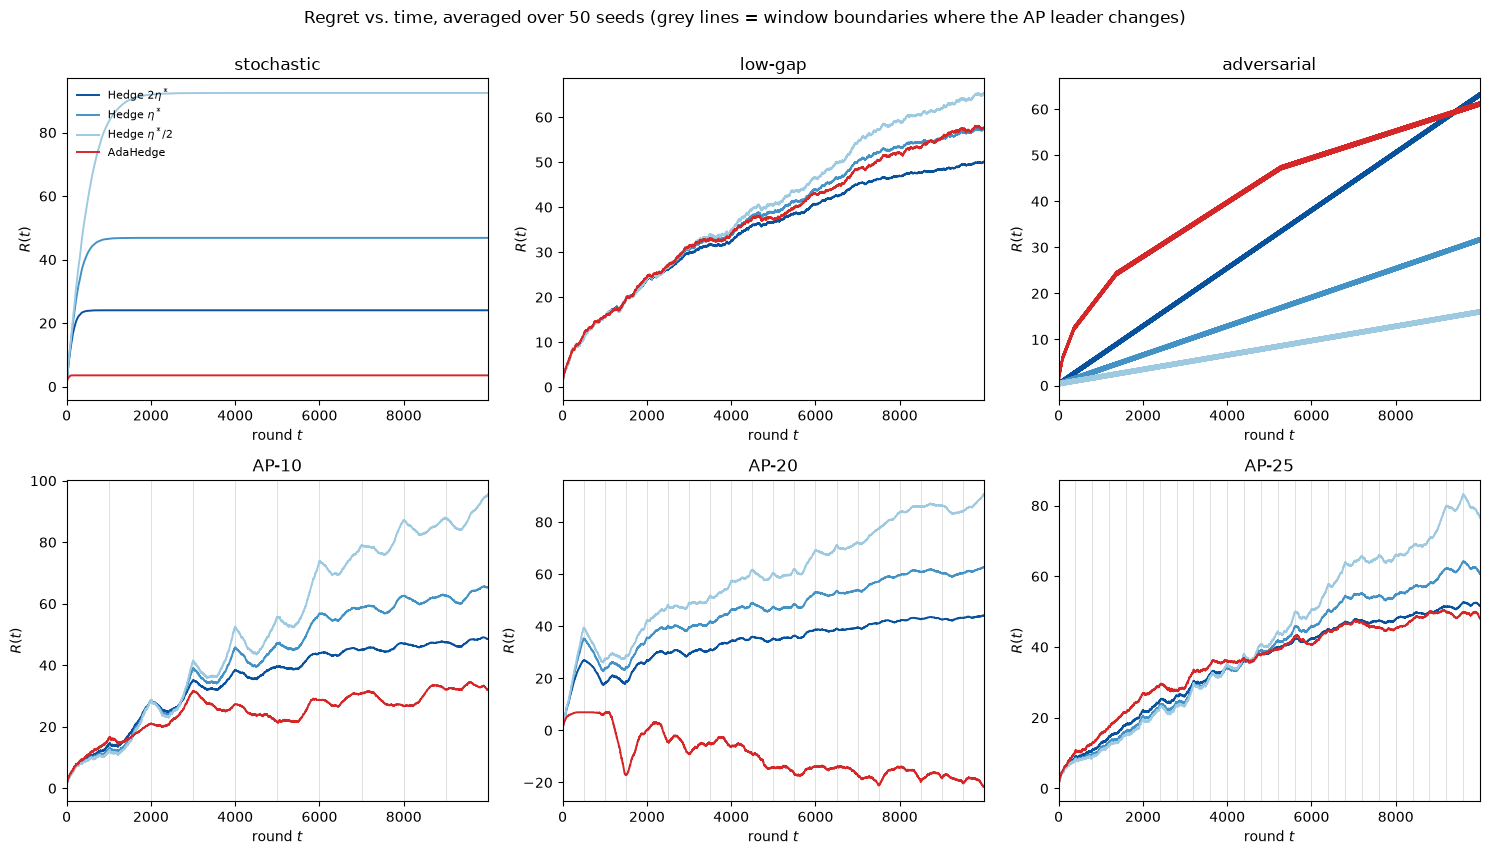

In [8]:
def grid(figsize=(15, 8.5)):
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    return fig, dict(zip(REGIMES, axes.ravel()))

fig, ax = grid()
for r in REGIMES:
    for a in ALGOS:
        ax[r].plot(mean_reg[r][a], color=COLOR[a], lw=1.4, label=LABEL[a])
    if r in AP_REGIMES:
        for b in meta_of[r]["boundaries"]:
            ax[r].axvline(b, color="0.85", lw=0.6, zorder=0)
    ax[r].set_title(r); ax[r].set_xlabel("round $t$"); ax[r].set_ylabel("$R(t)$")
    ax[r].margins(x=0)
ax["stochastic"].legend(fontsize=8, frameon=False)
fig.suptitle("Regret vs. time, averaged over 50 seeds "
             "(grey lines = window boundaries where the AP leader changes)", y=1.0)
fig.tight_layout(); fig.savefig(FIGDIR / "regret_vs_time.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 7. Cumulative loss vs. time

The dashed grey line is the running best action $\min_k L_t^k$ — the comparator the regret is
measured against.

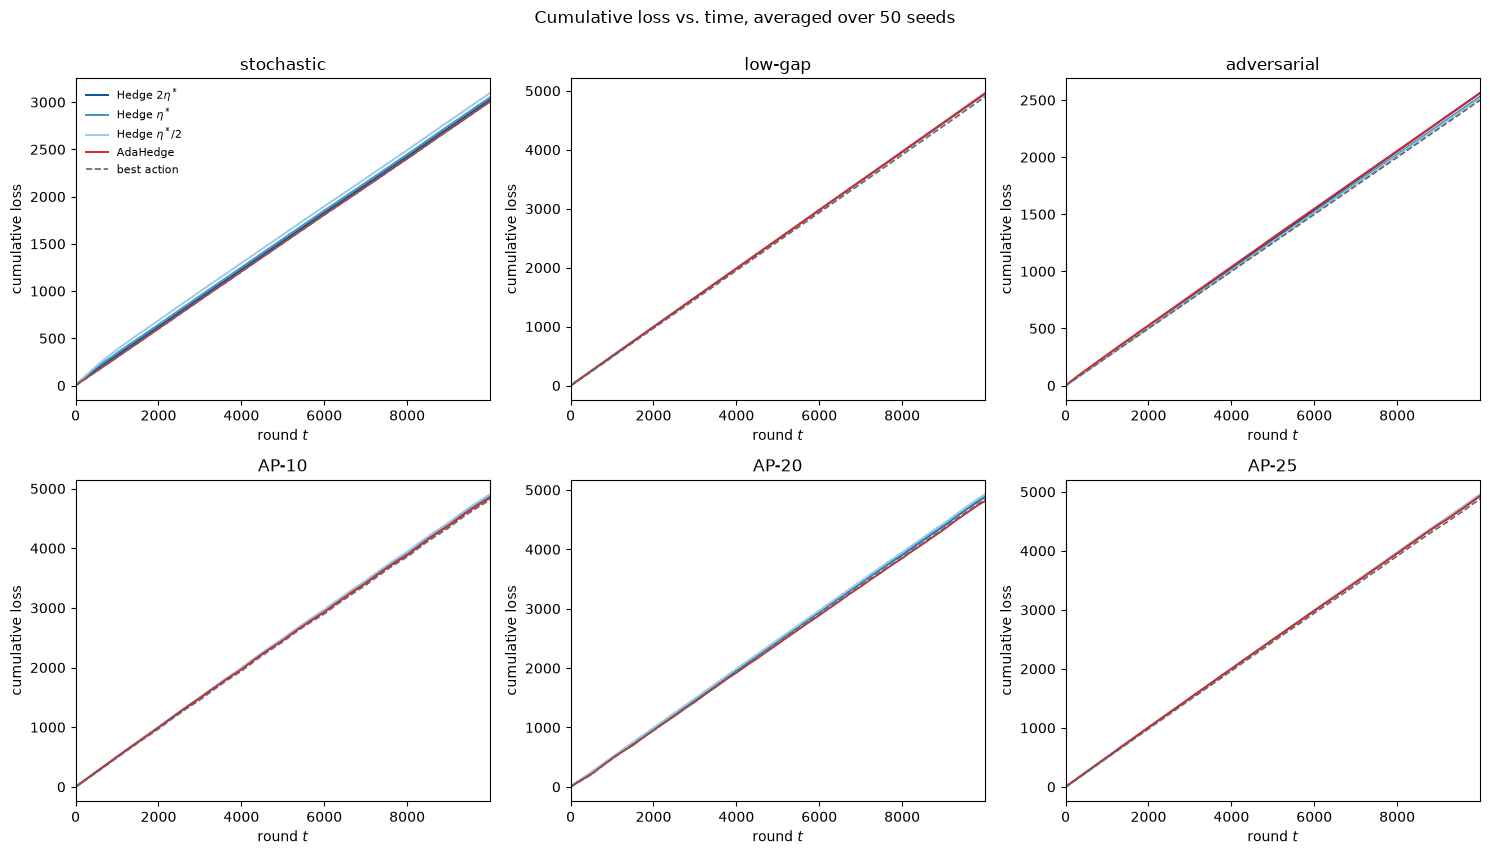

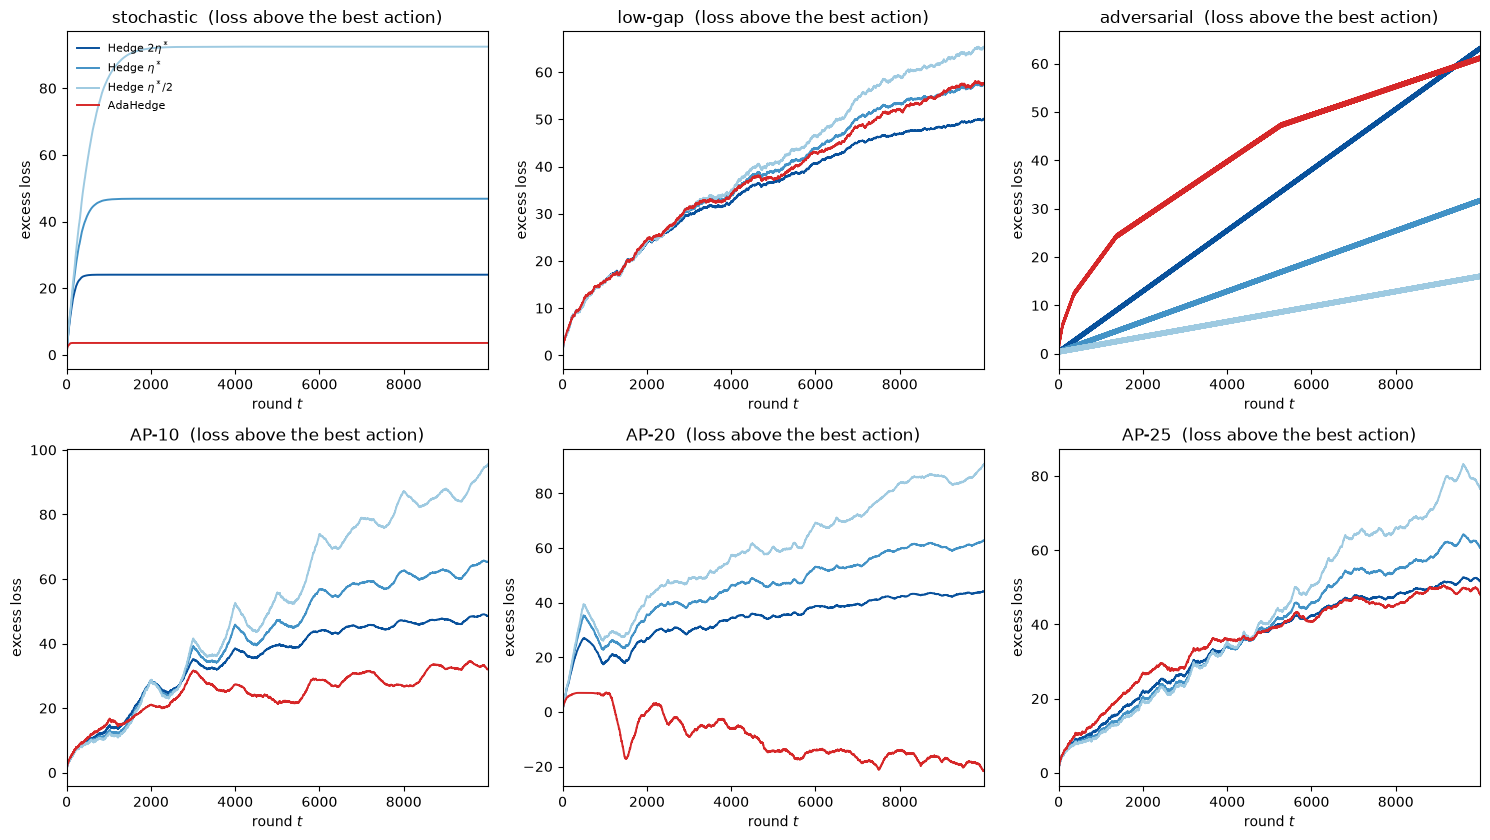

In [9]:
fig, ax = grid()
for r in REGIMES:
    for a in ALGOS:
        ax[r].plot(mean_cum[r][a], color=COLOR[a], lw=1.4, label=LABEL[a])
    ax[r].plot(mean_best[r], color="0.4", lw=1.2, ls="--", label="best action")
    ax[r].set_title(r); ax[r].set_xlabel("round $t$"); ax[r].set_ylabel("cumulative loss")
    ax[r].margins(x=0)
ax["stochastic"].legend(fontsize=8, frameon=False)
fig.suptitle("Cumulative loss vs. time, averaged over 50 seeds", y=1.0)
fig.tight_layout(); fig.savefig(FIGDIR / "cumloss_vs_time.png", dpi=130, bbox_inches="tight")
plt.show()

# the curves are nearly on top of each other; show the gap directly
fig, ax = grid(figsize=(15, 8.5))
for r in REGIMES:
    for a in ALGOS:
        ax[r].plot(mean_cum[r][a] - mean_best[r], color=COLOR[a], lw=1.4, label=LABEL[a])
    ax[r].set_title(r + "  (loss above the best action)")
    ax[r].set_xlabel("round $t$"); ax[r].set_ylabel("excess loss"); ax[r].margins(x=0)
ax["stochastic"].legend(fontsize=8, frameon=False)
fig.tight_layout(); fig.savefig(FIGDIR / "excess_loss.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 8. AdaHedge restarts vs. the AP window boundaries

AdaHedge starts a new segment when its budget is exhausted. In the AP regimes the leader changes at
every window boundary, so the natural question is whether the restarts *track the leader changes*.

For each AP regime we report the mean round of the $j$-th segment start, and, for the restarts after
the first, the mean distance to the closest window boundary. If restarts fell at rounds unrelated to
the boundaries, that distance would average $W/4$ — that is the null this table is read against.


=== AP-10   window width W = 1000, boundaries at rounds 1000, 2000, ..., 9000
    segments per seed: mean 4.98, min 4, max 5
      j  seeds with a j-th restart   mean round        sd
      1                         50          0.0       0.0
      2                         50         62.4      74.0
      3                         50        210.3     119.5
      4                         50        643.5     171.2
      5                         49       3023.8    1039.5
    restarts after the first: n = 199, mean distance to nearest boundary 597.0 (null W/4 = 250.0)

=== AP-20   window width W = 500, boundaries at rounds 500, 1000, ..., 9500
    segments per seed: mean 4.68, min 4, max 5
      j  seeds with a j-th restart   mean round        sd
      1                         50          0.0       0.0
      2                         50        291.3     402.8
      3                         50       1025.0     459.0
      4                         50       2600.0     917.2
      5       

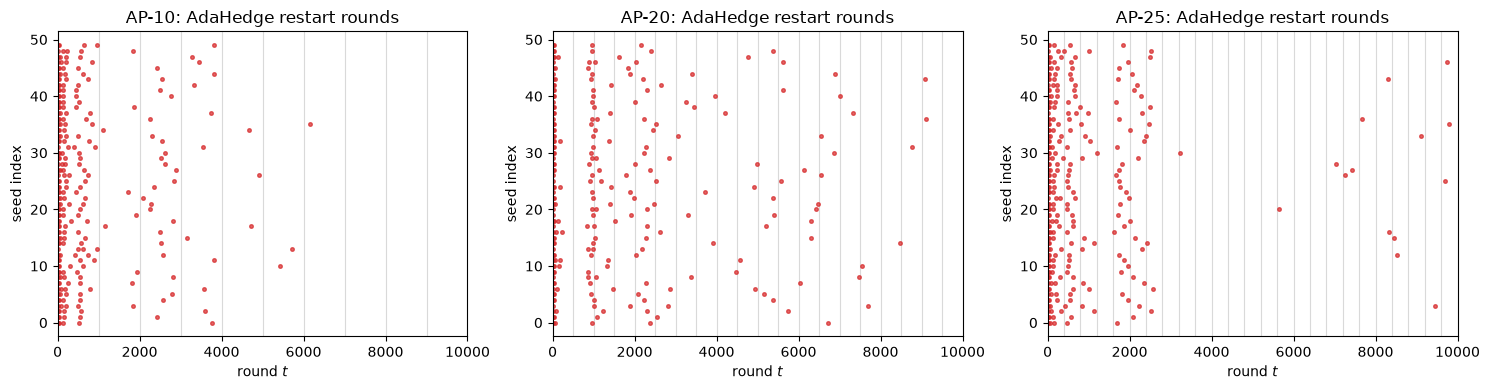

In [10]:
ap_summary = {}
for r in AP_REGIMES:
    W, nb = meta_of[r]["W"], meta_of[r]["boundaries"]
    nseg = np.array([len(s) for s in ada_star[r]])
    jmax = nseg.max()

    print(f"\n=== {r}   window width W = {W}, "
          f"boundaries at rounds {nb[0]}, {nb[1]}, ..., {nb[-1]}")
    print(f"    segments per seed: mean {nseg.mean():.2f}, min {nseg.min()}, max {nseg.max()}")
    print(f"    {'j':>3} {'seeds with a j-th restart':>26} {'mean round':>12} {'sd':>9}")
    rec = []
    for j in range(jmax):
        rounds = np.array([s[j] for s in ada_star[r] if len(s) > j], dtype=float)
        print(f"    {j+1:3d} {len(rounds):26d} {rounds.mean():12.1f} {rounds.std():9.1f}")
        rec.append([j + 1, len(rounds), float(rounds.mean()), float(rounds.std())])

    d = np.array([])
    later = np.concatenate([s[1:] for s in ada_star[r] if len(s) > 1]).astype(float)
    if later.size:
        d = np.abs(later[:, None] - nb[None, :]).min(axis=1)
        print(f"    restarts after the first: n = {later.size}, "
              f"mean distance to nearest boundary {d.mean():.1f} "
              f"(null W/4 = {W / 4:.1f})")
    ap_summary[r] = {"W": W, "starts": rec,
                     "mean_dist": float(d.mean()) if later.size else None,
                     "null_dist": W / 4}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axi, r in zip(axes, AP_REGIMES):
    for b in meta_of[r]["boundaries"]:
        axi.axvline(b, color="0.85", lw=0.8, zorder=0)
    for i, s in enumerate(ada_star[r]):
        axi.plot(s, np.full(len(s), i), "o", ms=2.6, color=COLOR["AdaHedge"], alpha=.7)
    axi.set_title(f"{r}: AdaHedge restart rounds"); axi.set_xlabel("round $t$")
    axi.set_ylabel("seed index"); axi.set_xlim(0, T)
fig.tight_layout(); fig.savefig(FIGDIR / "ap_restarts.png", dpi=130, bbox_inches="tight")
plt.show()

---
## 9. Weight per action vs. time, actions ranked by final loss

Within each seed the actions are sorted by their cumulative loss at $t=T$, so *rank 1* is the best
action in hindsight for that seed; the curves are then averaged across seeds. Ranking is necessary
because the identity of the best action changes from seed to seed (and, in the AP regimes, from
window to window), so averaging $w_t^k$ at fixed index $k$ would wash the structure out.

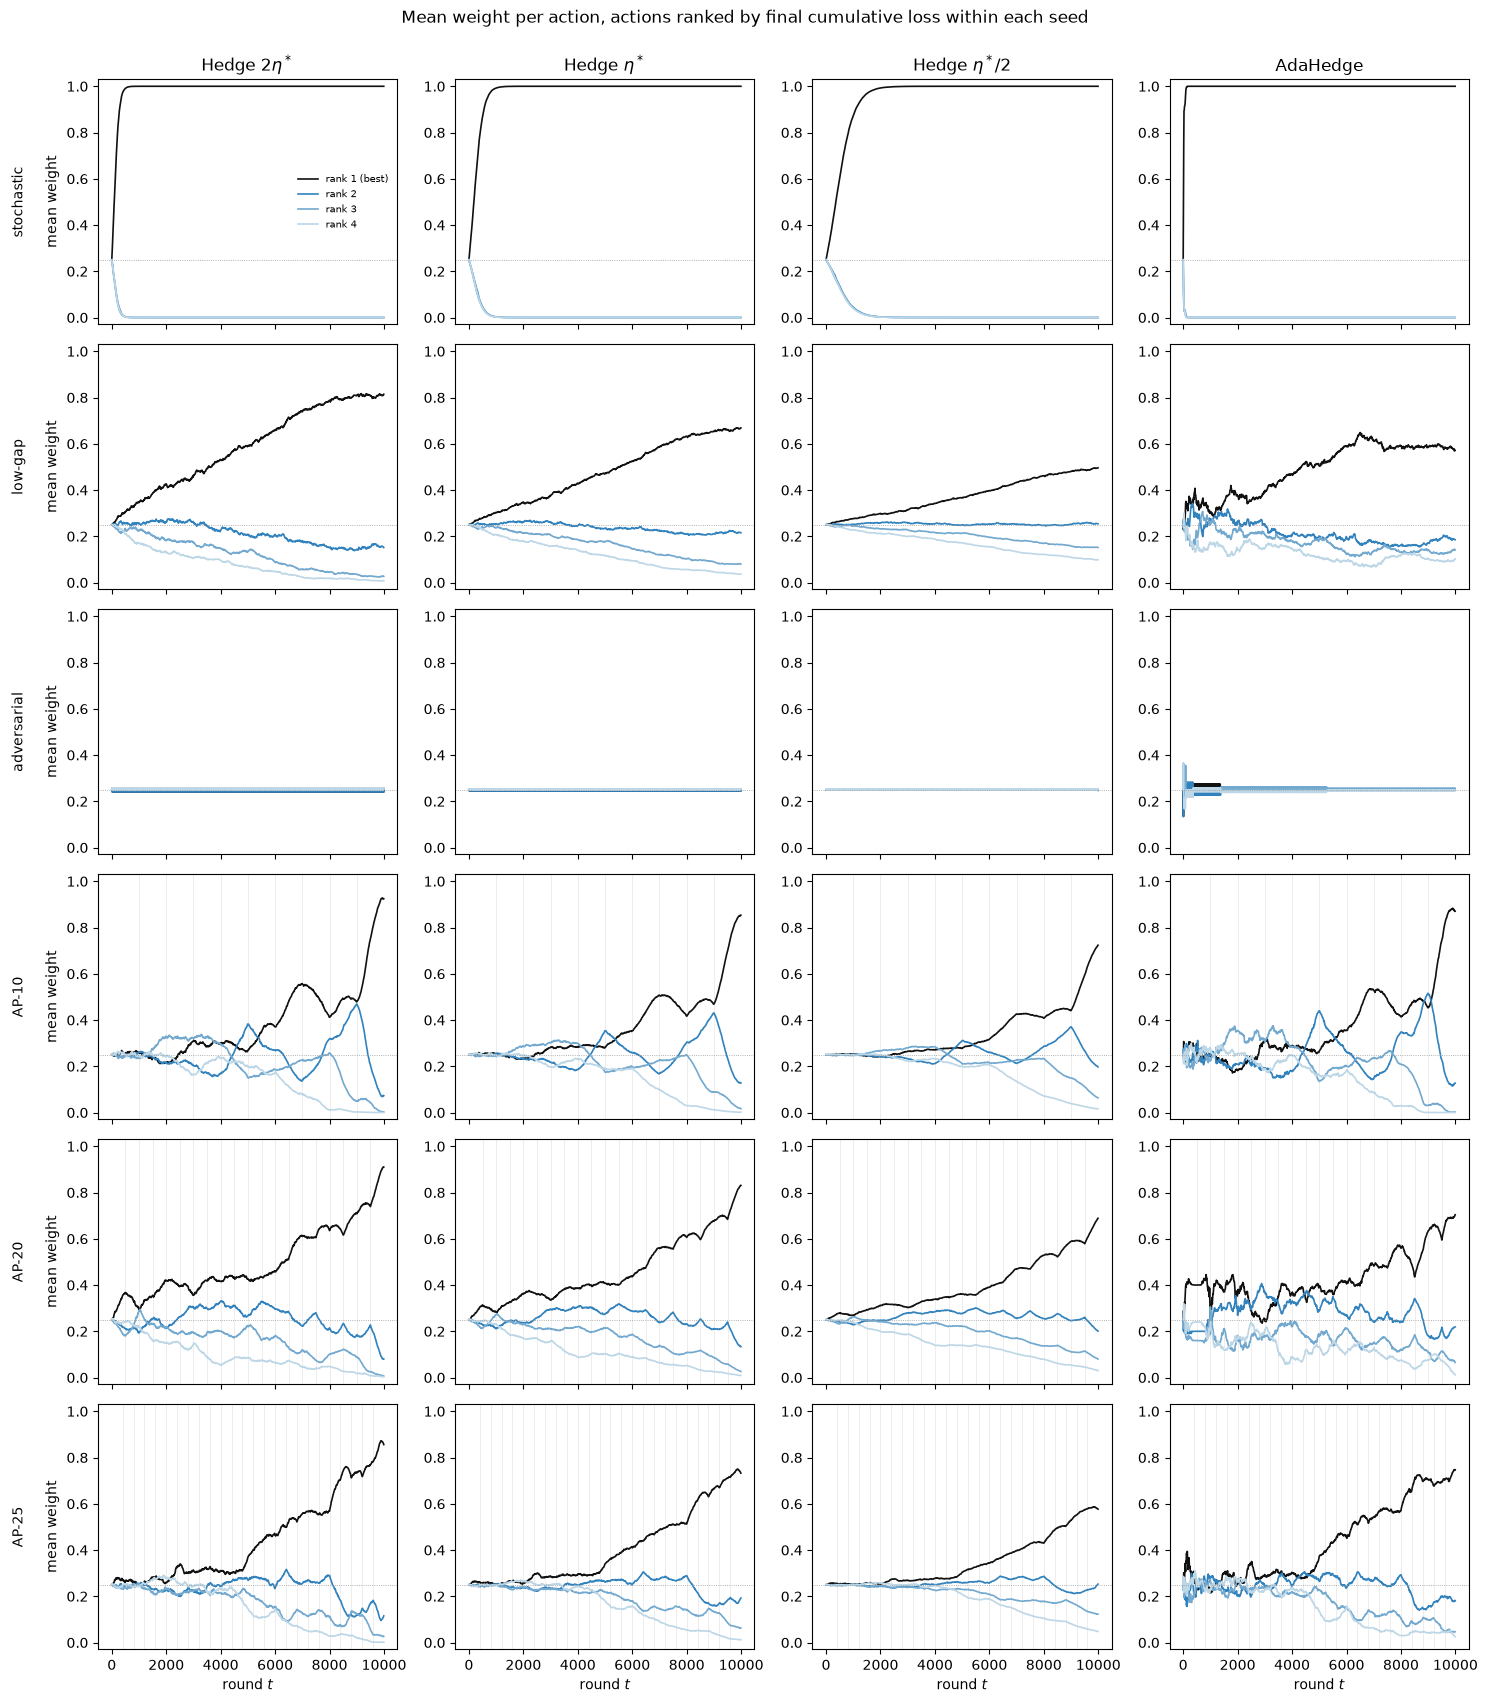

In [11]:
STEP = 10                                             # subsample for plotting only
RANKC = ["#111111", "#3182bd", "#74a9cf", "#bdd7e7"]

fig, axes = plt.subplots(len(REGIMES), len(ALGOS), figsize=(15, 17), sharex=True)
for i, r in enumerate(REGIMES):
    for j, a in enumerate(ALGOS):
        axi = axes[i, j]
        for k in range(K):
            axi.plot(np.arange(0, T, STEP), mean_w[r][a][::STEP, k],
                     color=RANKC[k], lw=1.2,
                     label=f"rank {k+1}" + (" (best)" if k == 0 else ""))
        if r in AP_REGIMES:
            for b in meta_of[r]["boundaries"]:
                axi.axvline(b, color="0.9", lw=0.5, zorder=0)
        axi.axhline(1 / K, color="0.6", lw=0.6, ls=":")
        axi.set_ylim(-0.03, 1.03)
        if i == 0:
            axi.set_title(LABEL[a])
        if j == 0:
            axi.set_ylabel(f"{r}\n\nmean weight")
        if i == len(REGIMES) - 1:
            axi.set_xlabel("round $t$")
axes[0, 0].legend(fontsize=7, frameon=False, loc="center right")
fig.suptitle("Mean weight per action, actions ranked by final cumulative loss within each seed",
             y=0.999)
fig.tight_layout(); fig.savefig(FIGDIR / "weights_by_rank.png", dpi=115, bbox_inches="tight")
plt.show()

---
## 10. Reading the results against the theory

Fill this in from the numbers your run produced; the points below are the ones the design is meant
to expose.

1. **Direction of the $\eta$ ordering.** On easy data (`stochastic`) the regret should *decrease*
   in $\eta$: the worst-case rate $\eta^{*}$ is far too cautious when one action is clearly best.
   On antagonistic data the ordering should reverse. No single fixed rate can be right in both,
   which is the entire motivation for AdaHedge.

2. **AdaHedge on easy data.** Theorem 9 predicts $O(1)$ regret when one action has a strictly
   smaller expected loss. Check whether AdaHedge stays on a single segment with $\eta=1$ in the
   `stochastic` regime — bounded $\Delta_T$ means the budget is never depleted.

3. **AdaHedge does not dominate.** Every restart throws away the posterior and re-pays $\ln K$
   (Lemma 4: the regret is governed by the number of segments). Where AdaHedge loses to a
   well-tuned fixed rate, count its segments — that is where the loss comes from, and it is
   exactly the cost the JMLR 2014 successor removes by letting $\eta_t$ vary continuously.

4. **`low-gap` is a statistical limit, not an algorithmic one.** The signal is
   $0.01\,T=100$ against noise of order $\sqrt{T}=100$, so the best action is barely identifiable
   and no algorithm should look good here.

5. **`adversarial` is deterministic**, so its standard deviation is exactly 0 across the 50 seeds.
   Hedge tilts weight toward whichever action was spared most recently — which is precisely the
   action about to be hit — so its regret grows with $\eta$ rather than shrinking.

6. **Weights in the `adversarial` panel look flat.** All four actions finish at exactly $2500$,
   so the ranking is a tie broken by index, and Hedge's weights oscillate with period $K$ around
   $1/K$ with an amplitude of order $\eta/K$ — a few thousandths at $\eta\approx0.03$, invisible on
   a $[0,1]$ axis. AdaHedge's early segments run at $\eta$ close to $1$, which is why only its
   panel shows visible oscillation before settling.

7. **AP restarts.** Compare the mean restart rounds with the window boundaries. If the restarts
   cluster early and then thin out, they are driven by the $\eta$-descent (a restart at rate $\eta$
   needs at least $b(\eta)/(\eta/8)$ rounds, which grows quadratically as $\eta$ falls), not by the
   leader changes.